In [10]:
import numpy as np
import matplotlib.pyplot as plt

# LWR model for 1D corridor

Model: LWR (Lighthill-Whitham-Richards) model for 1D corridor crowd dynamics. Equation: $$\partial_t \rho + \partial_x f(\rho) = 0,$$ where $\rho$ is the crowd density and $f(\rho) = V(\rho) \rho$ is the flux function. The velocity function $V(\rho)$ is typically decreasing with density, e.g., $V(\rho) = V_{\text{max}} (1 - \rho / \rho_{\text{max}})$.

In [ ]:
def base_flux(rho):
    """base flux f(rho) = rho(1-rho)."""
    return rho * (1.0 - rho)


def lax_friedrichs_flux(rho_L, rho_R, alpha=1.0):
    """Lax-Friedrichs numerical flux for the base flux."""
    return 0.5 * (base_flux(rho_L) + base_flux(rho_R)) - 0.5 * alpha * (rho_R - rho_L)


def eval_boundary_value(bc, t):
    """
    evaluate a boundary specification at time t. bc can be None, a scalar, or a callable function of time.
    """
    if bc is None:
        return None
    if callable(bc):
        return float(bc(t))
    return float(bc)


def solve_lwr_corridor(
    initial_condition_fn,
    Nx=500,
    T=1.0,
    num_time_steps=1000,
    num_snapshots=20,
    CFL=0.8,
    alpha=1.0,
    rho_left=0.0,
    rho_right=None,
    capacity=lambda x: 1.0
):
    """
    Solve rho_t + (F(x,rho))_x = 0 on x in [0,1], with
        F(x,rho) = c(x) f(rho),
    using a finite-volume method.
    """
    # grid on [0,1]
    x_left, x_right = 0.0, 1.0
    dx = (x_right - x_left) / Nx
    x_centers = np.linspace(x_left + 0.5 * dx, x_right - 0.5 * dx, Nx)
    x_interfaces = np.linspace(x_left, x_right, Nx + 1)

    # time step
    dt = T / num_time_steps

    # snapshot times
    snapshot_times = np.linspace(0.0, T, num_snapshots)

    # initial condition
    rho = np.asarray(initial_condition_fn(x_centers), dtype=float).copy()

    # capacities at grid interfaces
    cap_interfaces = np.array([float(capacity(x)) for x in x_interfaces], dtype=float)

    # CFL diagnostic
    max_capacity = np.max(cap_interfaces)
    max_dt = CFL * dx / (max_capacity * alpha)
    if dt > max_dt:
        print(
            f"Warning: CFL condition violated (dt={dt:.4e} > max_dt={max_dt:.4e}). "
            "The scheme may be unstable."
        )

    saved_snapshots = {}
    next_snapshot_idx = 0
    time = 0.0

    # diagnostics
    mass_times = [0.0]
    masses = [dx * np.sum(rho)]
    left_fluxes = []
    right_fluxes = []
    cumulative_outflow = [0.0]

    # save initial state if needed
    while (
        next_snapshot_idx < len(snapshot_times)
        and time >= snapshot_times[next_snapshot_idx] - 1e-12
    ):
        saved_snapshots[float(snapshot_times[next_snapshot_idx])] = rho.copy()
        next_snapshot_idx += 1

    for _ in range(num_time_steps):
        interface_flux = np.zeros(Nx + 1)

        # evaluate boundary data at current time
        bc_left = eval_boundary_value(rho_left, time)
        bc_right = eval_boundary_value(rho_right, time)

        # left boundary flux
        if bc_left is None:
            raw_flux = base_flux(rho[0])
        else:
            raw_flux = lax_friedrichs_flux(bc_left, rho[0], alpha=alpha)
        interface_flux[0] = cap_interfaces[0] * raw_flux

        # interior fluxes
        for j in range(1, Nx):
            raw_flux = lax_friedrichs_flux(rho[j - 1], rho[j], alpha=alpha)
            interface_flux[j] = cap_interfaces[j] * raw_flux

        # right boundary flux
        if bc_right is None:
            raw_flux = base_flux(rho[-1])
        else:
            raw_flux = lax_friedrichs_flux(rho[-1], bc_right, alpha=alpha)
        interface_flux[Nx] = cap_interfaces[Nx] * raw_flux

        # conservative update
        rho -= (dt / dx) * (interface_flux[1:] - interface_flux[:-1])

        time += dt

        # diagnostics
        left_fluxes.append(interface_flux[0])
        right_fluxes.append(interface_flux[Nx])
        masses.append(dx * np.sum(rho))
        mass_times.append(time)
        cumulative_outflow.append(cumulative_outflow[-1] + dt * interface_flux[Nx])

        # save snapshots
        while (
            next_snapshot_idx < len(snapshot_times)
            and time >= snapshot_times[next_snapshot_idx] - 1e-12
        ):
            saved_snapshots[float(snapshot_times[next_snapshot_idx])] = rho.copy()
            next_snapshot_idx += 1

    diagnostics = {
        "times": np.array(mass_times),
        "masses": np.array(masses),
        "left_fluxes": np.array(left_fluxes),
        "right_fluxes": np.array(right_fluxes),
        "cumulative_outflow": np.array(cumulative_outflow),
        "initial_mass": masses[0],
        "dx": dx,
        "dt": dt,
        "x_interfaces": x_interfaces,
        "capacities": cap_interfaces,
    }

    return x_centers, saved_snapshots, diagnostics

In [132]:
### helpers for plotting 

def plot_density_snapshots(x_coords, density_by_time, title="1D corridor crowd model: finite volume LWR", cmap_name="viridis"):
    # sort times so lines and colors follow temporal order
    times = sorted(density_by_time)
    colormap = plt.colormaps[cmap_name]
    norm = plt.Normalize(vmin=min(times), vmax=max(times))

    fig, ax = plt.subplots(figsize=(8, 5))
    for current_time in times:
        ax.plot(x_coords, density_by_time[current_time], color=colormap(norm(current_time)), linewidth=2)

    # add a colorbar to map color -> time
    scalar_map = plt.cm.ScalarMappable(norm=norm, cmap=colormap)
    scalar_map.set_array([])
    colorbar = fig.colorbar(scalar_map, ax=ax)
    colorbar.set_label("time")

    ax.set_xlabel("x")
    ax.set_ylabel("density rho")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()


def create_density_animation(x_coords, density_by_time, filename="density_animation.gif", title="1D corridor crowd model: finite volume LWR", cmap_name="viridis", fps=3):
    """Create an animated GIF of density snapshots over time.
    """
    from PIL import Image
    import io

    times = sorted(density_by_time.keys())
    rho_min = min(np.min(density_by_time[t]) for t in times)
    rho_max = max(np.max(density_by_time[t]) for t in times)

    frames = []

    for current_time in times:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(x_coords, density_by_time[current_time], linewidth=2, color="steelblue")
        ax.set_xlabel("x")
        ax.set_ylabel("density rho")
        ax.set_title(f"{title} (t = {current_time:.3f})")
        ax.set_ylim([rho_min - 0.05, rho_max + 0.05])
        ax.grid(True, alpha=0.3)
        fig.tight_layout()

        # convert current figure to a png frame in memory
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=100)
        buf.seek(0)
        frames.append(Image.open(buf).copy())
        plt.close(fig)

    # save all frames to a looping gif
    frames[0].save(
        filename,
        save_all=True,
        append_images=frames[1:],
        duration=int(1000 / fps),
        loop=0,
    )
    print(f"Animation saved to {filename}")

def plot_mass_convervation(diagnostics):

    balance = diagnostics["masses"] + diagnostics["cumulative_outflow"]
    plt.figure(figsize=(8, 5))
    plt.plot(diagnostics["times"], diagnostics["masses"], label="Mass inside corridor")
    plt.plot(diagnostics["times"], balance, label="Mass + cumulative outflow")
    plt.axhline(diagnostics["initial_mass"], color="k", linestyle="--", label="Initial mass")
    plt.xlabel("time")
    plt.ylabel("mass")
    plt.title("Mass conservation check")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Initial mass:", diagnostics["initial_mass"])
    print("Final balance error:", balance[-1] - diagnostics["initial_mass"])

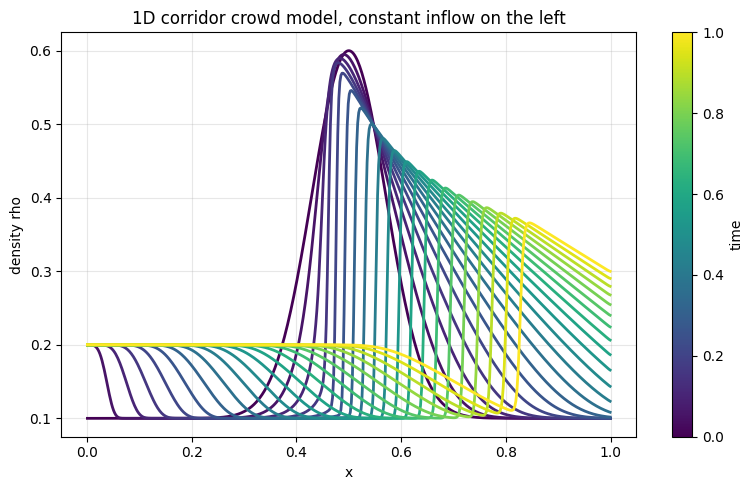

In [ ]:
# constant inflow state on the left, free outflow on the right
# initial condition is a bump in the middle of the corridor
initial_condition_fn = lambda x: 0.1 + 0.5 * np.exp(-100 * (x - 0.5) ** 2)

x, snaps, diag = solve_lwr_corridor(
    initial_condition_fn,
    rho_left=0.2,
    rho_right=None,
)

#plot_density_snapshots(x, snaps, title="1D corridor crowd model, constant inflow on the left")

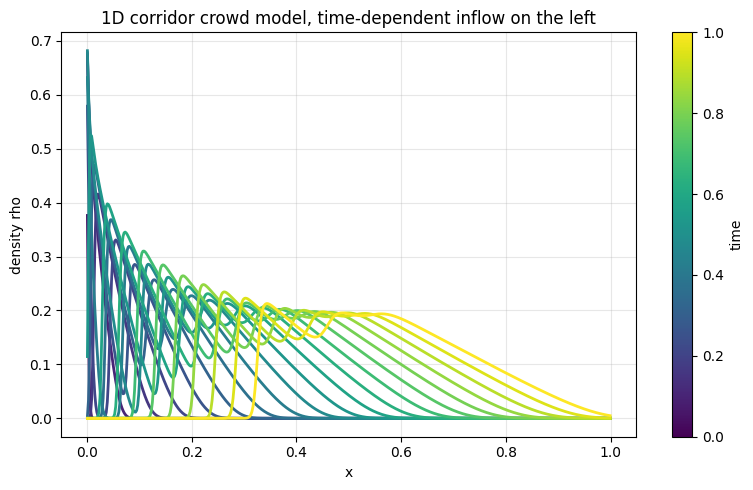

Animation saved to lwr_corridor.gif


In [194]:
# time-dependent inflow on the left, initial condition 0 everywhere
initial_condition_fn = lambda x: 0.0*x


def inflow_left(starts, durations, amplitudes):
    """ waves of different amplitudes and durations starting at different times """
    def inflow_fn(t):
        total = 0.0
        for start, duration, amplitude in zip(starts, durations, amplitudes):
            if start <= t < start + duration:
                total += amplitude
        return total
    return inflow_fn

x, snaps, diag = solve_lwr_corridor(
    initial_condition_fn,
    rho_left=inflow_left(starts=[0.05, 0.20, 0.40],
                         durations=[0.08, 0.10, 0.12],
                         amplitudes=[1.0, 1.0, 1.0]),
    rho_right = None,
    T = 1.0,
    num_time_steps=5000,
)

plot_density_snapshots(x, snaps, title="1D corridor crowd model, time-dependent inflow on the left")

# mass conservation check
#plot_mass_convervation(diag)

# gif
create_density_animation(x, snaps, filename="lwr_corridor.gif", title="1D corridor crowd model: finite volume LWR, time-dependent inflow on the left", fps=5)

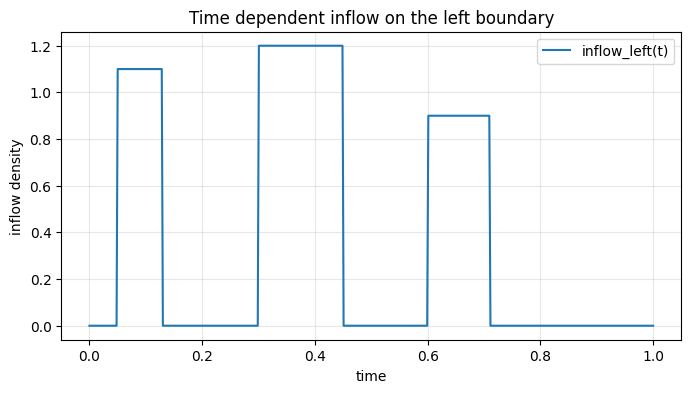

In [183]:
# plot inflow_left

t_values = np.linspace(0, 1, 500)
inflow_values = [inflow_left(starts=[0.05, 0.30, 0.60],
                         durations=[0.08, 0.15, 0.11],
                         amplitudes=[1.1, 1.2, 0.9])(t) for t in t_values]
plt.figure(figsize=(8, 4))
plt.plot(t_values, inflow_values, label="inflow_left(t)")
plt.xlabel("time")
plt.ylabel("inflow density")
plt.title("Time dependent inflow on the left boundary")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

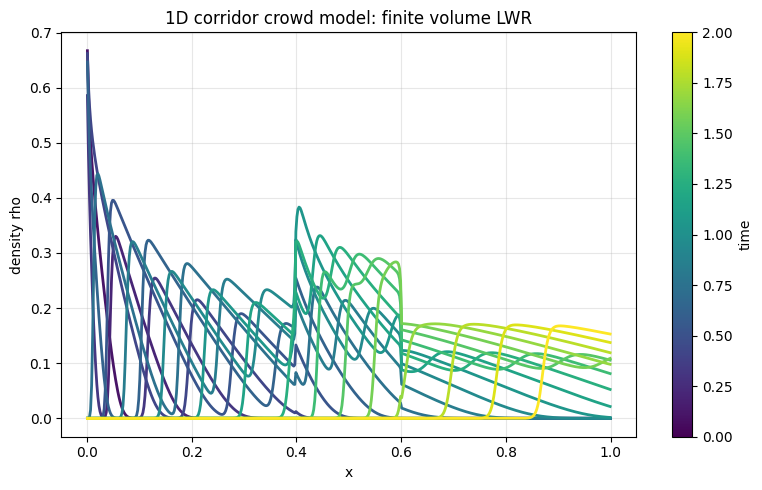

Animation saved to density_animation.gif


In [192]:
# bottolnekked corridor for runners
def bottleneck_capacity(x):
    if 0.4 <= x <= 0.6:
        return 0.7 # less capacity in the bottleneck
    return 1.0

x, snapshots, diagnostics = solve_lwr_corridor(
    initial_condition_fn=lambda x: 0*x,
    capacity=bottleneck_capacity,
    rho_left=inflow_left(starts=[0.05, 0.30, 0.60],
                         durations=[0.08, 0.15, 0.11],
                         amplitudes=[1.1, 1.2, 0.9]),
    T = 2,
    num_time_steps=10000,
    num_snapshots=20
)

plot_density_snapshots(x, snapshots)

# make gif
create_density_animation(x, snapshots)

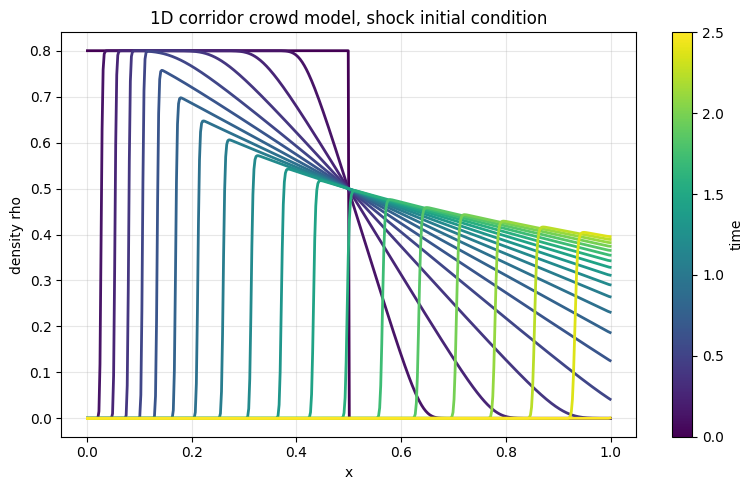

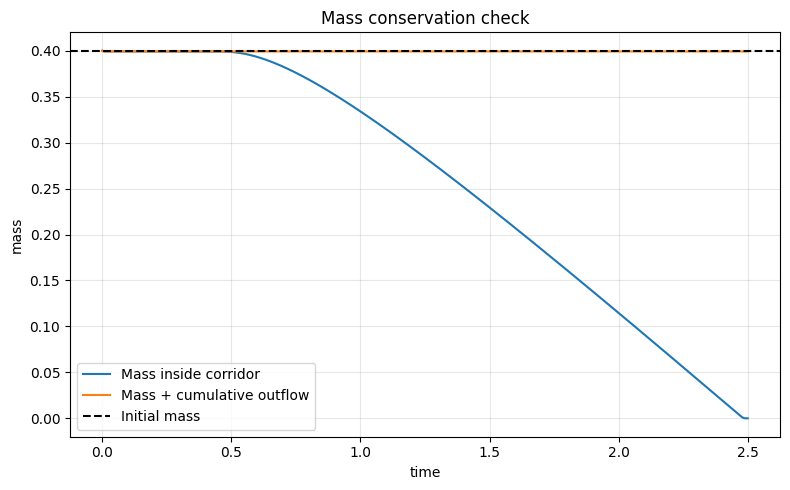

Initial mass: 0.4000000000000001
Final balance error: -0.0007634146012181486


In [ ]:
# density only on first half of the corridor, free outflow on the right, no inflow on the left
initial_density_shock = lambda x: np.where(x < 0.5, 0.8, 0.0)

x, snaps, diag = solve_lwr_corridor(
    initial_density_shock,
    rho_left=0.0, # no inflow on the left, just the initial shock
    rho_right=None, # free outflow on the right
    T = 2.5,
    num_time_steps=10000,
)

plot_density_snapshots(x, snaps, title="1D corridor crowd model, shock initial condition")

# mass conservation check
#plot_mass_convervation(diag)

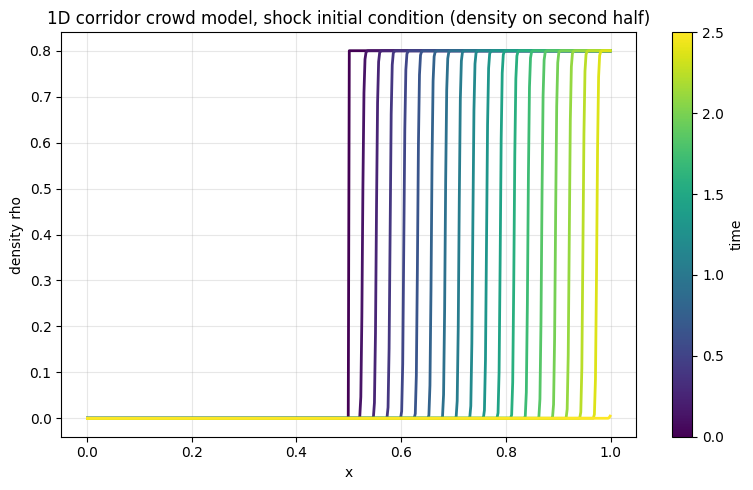

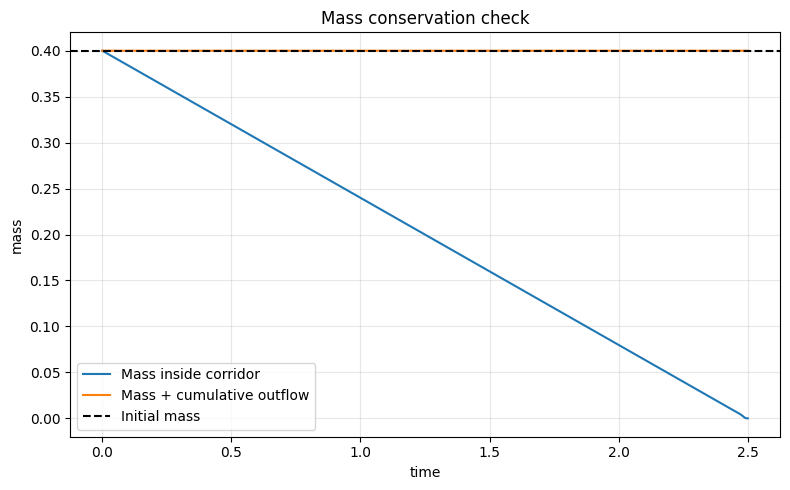

Initial mass: 0.4
Final balance error: -1.2378986724570495e-14


In [162]:
# density only on second half of the corridor, free outflow on the right, no inflow on the left
initial_density_shock2 = lambda x: np.where(x < 0.5, 0.0, 0.8)

x, snaps, diag = solve_lwr_corridor(
    initial_density_shock2,
    rho_left=0.0, # no inflow on the left, just the initial shock
    rho_right=None, # free outflow on the right
    T = 2.5,
    num_time_steps=10000,
)
plot_density_snapshots(x, snaps, title="1D corridor crowd model, shock initial condition (density on second half)")

# mass conservation check
plot_mass_convervation(diag)

# gif
#create_density_animation(x, snaps, filename="lwr_corridor_shock.gif", title="1D corridor crowd model: finite volume LWR, shock initial condition", fps=5)